# 🔍 03 — LSH Pipeline Demo

Test toàn bộ LSH pipeline: Shingling → MinHash → Banding → Query.

**Tham số:** k=3, n=100, b=20, r=5 → threshold ≈ 0.55

## 3.1 Setup

In [ ]:
import os, sys
# Databricks Free Edition (Serverless) auto-mounts Git folders under /Workspace/Repos/.
_in_databricks = os.path.exists("/Workspace") and "DATABRICKS_RUNTIME_VERSION" in os.environ
if _in_databricks:
    os.environ.setdefault("LSH_ENV", "databricks")
    _candidates = [os.getcwd()] + [
        f"/Workspace/Repos/{os.environ.get('USER', '')}/lsh-book-recommendation"
    ]
    _repo_root = next(
        (p for p in _candidates
         if os.path.isdir(os.path.join(p, "config")) and os.path.isdir(os.path.join(p, "src"))),
        os.getcwd(),
    )
    if _repo_root not in sys.path:
        sys.path.insert(0, _repo_root)
    os.environ.setdefault(
        "NLTK_DATA",
        "/Volumes/workspace/lsh_book_recommendation/data/nltk_data",
    )
else:
    if os.path.basename(os.getcwd()) == "notebooks":
        os.chdir(os.path.abspath(os.path.join(os.getcwd(), "..")))
    sys.path.insert(0, ".")

from config.settings import config
print(f"k={config.SHINGLE_K}, n={config.MINHASH_NUM_HASHES}")
print(f"b={config.LSH_NUM_BANDS}, r={config.LSH_ROWS_PER_BAND}")


## 3.2 Prepare sample data

Dùng vài đoạn text ngắn để test trước (không cần Spark).

In [2]:
# Small test corpus — dễ verify bằng tay
docs = {
    'doc_A': 'the quick brown fox jumps over the lazy dog near the river bank',
    'doc_B': 'the quick brown fox leaps over the lazy dog near the river',     # very similar to A
    'doc_C': 'a fast dark wolf runs across the sleepy cat by the stream',       # somewhat similar
    'doc_D': 'machine learning algorithms process large datasets efficiently',   # completely different
}

print(f"Test corpus: {len(docs)} documents")

Test corpus: 4 documents


## 3.3 Step 1 — k-Shingling

In [3]:
## 3.3 Step 1 — k-Shingling (Pure Python)

import hashlib

def create_word_shingles(text, k=3):
    """Create set of word k-shingles from text."""
    words = text.lower().split()
    return set(" ".join(words[i:i+k]) for i in range(len(words) - k + 1))

# Generate shingles for all docs
shingle_sets = {name: create_word_shingles(text, k=config.SHINGLE_K) for name, text in docs.items()}

for name, shingles in shingle_sets.items():
    print(f"\n{name} ({len(shingles)} shingles):")
    for s in sorted(shingles)[:5]:
        print(f"  '{s}'")
    if len(shingles) > 5:
        print(f"  ... and {len(shingles) - 5} more")

# Overlap between A and B
overlap = shingle_sets['doc_A'] & shingle_sets['doc_B']
print(f"\nOverlap(A,B): {len(overlap)} shingles → {sorted(overlap)[:5]}")


doc_A (11 shingles):
  'brown fox jumps'
  'dog near the'
  'fox jumps over'
  'jumps over the'
  'lazy dog near'
  ... and 6 more

doc_B (10 shingles):
  'brown fox leaps'
  'dog near the'
  'fox leaps over'
  'lazy dog near'
  'leaps over the'
  ... and 5 more

doc_C (10 shingles):
  'a fast dark'
  'across the sleepy'
  'by the stream'
  'cat by the'
  'dark wolf runs'
  ... and 5 more

doc_D (5 shingles):
  'algorithms process large'
  'large datasets efficiently'
  'learning algorithms process'
  'machine learning algorithms'
  'process large datasets'

Overlap(A,B): 7 shingles → ['dog near the', 'lazy dog near', 'near the river', 'over the lazy', 'quick brown fox']


## 3.4 Compute exact Jaccard similarity (ground truth)

In [4]:
## 3.4 Exact Jaccard Similarity (Ground Truth)

def jaccard(set_a, set_b):
    """Compute exact Jaccard similarity between two sets."""
    if not set_a and not set_b:
        return 0.0
    return len(set_a & set_b) / len(set_a | set_b)

# Compute all pairwise Jaccard similarities
doc_names = list(docs.keys())
print("Exact Jaccard similarities:")
print(f"{'':>8}", end="")
for name in doc_names:
    print(f"{name:>8}", end="")
print()

for i, name_i in enumerate(doc_names):
    print(f"{name_i:>8}", end="")
    for j, name_j in enumerate(doc_names):
        j_val = jaccard(shingle_sets[name_i], shingle_sets[name_j])
        print(f"{j_val:>8.3f}", end="")
    print()

Exact Jaccard similarities:
           doc_A   doc_B   doc_C   doc_D
   doc_A   1.000   0.500   0.000   0.000
   doc_B   0.500   1.000   0.000   0.000
   doc_C   0.000   0.000   1.000   0.000
   doc_D   0.000   0.000   0.000   1.000


## 3.5 Step 2 — MinHash signatures

In [5]:
## 3.5 MinHash Signatures (Pure Python)

import random

LARGE_PRIME = (1 << 31) - 1

def stable_hash(s):
    """Deterministic hash using md5."""
    return int(hashlib.md5(s.encode("utf-8")).hexdigest(), 16) % LARGE_PRIME

def generate_hash_functions(n, seed=42):
    """Generate n universal hash function params (a, b)."""
    rng = random.Random(seed)
    return [(rng.randint(1, LARGE_PRIME - 1), rng.randint(0, LARGE_PRIME - 1)) for _ in range(n)]

def compute_signature(shingle_set, hash_params):
    """Compute MinHash signature for a shingle set."""
    sig = []
    for a, b in hash_params:
        min_val = LARGE_PRIME
        for s in shingle_set:
            h = stable_hash(s)
            val = ((a * h + b) % LARGE_PRIME) % LARGE_PRIME
            min_val = min(min_val, val)
        sig.append(min_val)
    return sig

def estimate_jaccard(sig_a, sig_b):
    """Estimate Jaccard from two signatures."""
    return sum(1 for a, b in zip(sig_a, sig_b) if a == b) / len(sig_a)

# Generate signatures
n_hashes = config.MINHASH_NUM_HASHES
hash_params = generate_hash_functions(n_hashes)
signatures = {name: compute_signature(shingles, hash_params) for name, shingles in shingle_sets.items()}

# Compare estimated vs exact Jaccard
print(f"MinHash signatures (n={n_hashes}):\n")
print(f"{'Pair':<16} {'Exact J':>8} {'Est J':>8} {'Error':>8}")
print("-" * 44)
for i, name_i in enumerate(doc_names):
    for j, name_j in enumerate(doc_names):
        if i < j:
            exact = jaccard(shingle_sets[name_i], shingle_sets[name_j])
            est = estimate_jaccard(signatures[name_i], signatures[name_j])
            print(f"{name_i+','+name_j:<16} {exact:>8.3f} {est:>8.3f} {abs(exact-est):>8.3f}")

MinHash signatures (n=50):

Pair              Exact J    Est J    Error
--------------------------------------------
doc_A,doc_B         0.500    0.400    0.100
doc_A,doc_C         0.000    0.000    0.000
doc_A,doc_D         0.000    0.000    0.000
doc_B,doc_C         0.000    0.000    0.000
doc_B,doc_D         0.000    0.000    0.000
doc_C,doc_D         0.000    0.000    0.000


## 3.6 Step 3 — LSH Banding

In [6]:
## 3.6 LSH Banding (Pure Python)

import struct

def hash_band(values):
    """Deterministic band hash using md5."""
    data = struct.pack(f">{len(values)}i", *values)
    return int(hashlib.md5(data).hexdigest(), 16) % LARGE_PRIME

def build_lsh_buckets(signatures, num_bands, rows_per_band):
    """Split signatures into bands, hash each band to bucket."""
    buckets = {}  # (band_id, bucket_hash) → [doc_names]
    for name, sig in signatures.items():
        for b in range(num_bands):
            band_values = sig[b * rows_per_band:(b + 1) * rows_per_band]
            bucket = hash_band(band_values)
            key = (b, bucket)
            buckets.setdefault(key, []).append(name)
    return buckets

b = config.LSH_NUM_BANDS
r = config.LSH_ROWS_PER_BAND
buckets = build_lsh_buckets(signatures, b, r)

# Show bucket assignments
print(f"LSH Banding: b={b} bands, r={r} rows per band\n")
shared_buckets = {k: v for k, v in buckets.items() if len(v) > 1}
print(f"Buckets with >1 doc ({len(shared_buckets)} shared):")
for (band_id, bucket_hash), members in sorted(shared_buckets.items()):
    print(f"  Band {band_id}, Bucket {bucket_hash}: {members}")

# Find candidate pairs
candidates = set()
for members in buckets.values():
    for i in range(len(members)):
        for j in range(i + 1, len(members)):
            candidates.add((members[i], members[j]) if members[i] < members[j] else (members[j], members[i]))

print(f"\nCandidate pairs: {candidates}")

LSH Banding: b=10 bands, r=5 rows per band

Buckets with >1 doc (0 shared):

Candidate pairs: set()


## 3.7 Step 4 — Query

In [7]:
## 3.7 Query — Find similar docs to doc_A

query_doc = 'doc_A'
print(f"Query: {query_doc}\n")

# Rank candidates by exact Jaccard
results = []
for name in docs:
    if name != query_doc:
        is_candidate = any(
            (min(query_doc, name), max(query_doc, name)) == pair
            for pair in candidates
        )
        exact_j = jaccard(shingle_sets[query_doc], shingle_sets[name])
        est_j = estimate_jaccard(signatures[query_doc], signatures[name])
        results.append((name, exact_j, est_j, is_candidate))

results.sort(key=lambda x: x[1], reverse=True)

print(f"{'Doc':<8} {'Exact J':>8} {'Est J':>8} {'Candidate':>10}")
print("-" * 38)
for name, exact_j, est_j, is_cand in results:
    marker = "✓" if is_cand else ""
    print(f"{name:<8} {exact_j:>8.3f} {est_j:>8.3f} {marker:>10}")

Query: doc_A

Doc       Exact J    Est J  Candidate
--------------------------------------
doc_B       0.500    0.400           
doc_C       0.000    0.000           
doc_D       0.000    0.000           


## 3.8 Verify with Spark

In [8]:
## 3.8 Verify with Spark — Full Pipeline using src modules
import os, sys

# Ensure project root is on path
os.chdir(os.path.join(os.path.dirname(os.getcwd()) if 'notebooks' in os.getcwd() else os.getcwd()))
sys.path.insert(0, '.')

from src.preprocessing import create_spark_session
from src.shingling import generate_shingles as spark_shingles
from src.minhash import compute_minhash_signatures as spark_minhash
from src.lsh import build_lsh_index, find_candidate_pairs

spark = create_spark_session()

# Load preprocessed Parquet from notebook 02
tokens_df = spark.read.parquet(config.DATA_CLEANED_PATH)
print(f"Loaded {tokens_df.count()} books from {config.DATA_CLEANED_PATH}")

# Shingling
shingles_df = spark_shingles(tokens_df)
print(f"Shingled: {shingles_df.count()} books")

# MinHash
signatures_df = spark_minhash(shingles_df, spark)
print(f"Signatures: {signatures_df.count()} books, length={config.MINHASH_NUM_HASHES}")

# LSH
lsh_index_df = build_lsh_index(signatures_df)
print(f"LSH index: {lsh_index_df.count()} rows")

# Candidate pairs
pairs_df = find_candidate_pairs(lsh_index_df)
n_pairs = pairs_df.count()
print(f"\nCandidate pairs: {n_pairs}")
pairs_df.show(10, truncate=False)

26/03/03 15:26:41 WARN Utils: Your hostname, MacBook-Air-cua-Tran.local resolves to a loopback address: 127.0.0.1; using 172.20.10.10 instead (on interface en0)
26/03/03 15:26:41 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/03 15:26:42 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Loaded 93 books from ./data/output/cleaned/


Shingled: 93 books


Signatures: 93 books, length=50


26/03/03 15:26:58 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors


LSH index: 930 rows



Candidate pairs: 5


+---------+---------+
|book_id_1|book_id_2|
+---------+---------+
|pg5097   |pg54873  |
|pg42324  |pg84     |
|pg41445  |pg42324  |
|pg42     |pg43     |
|pg41445  |pg84     |
+---------+---------+



## 3.9 S-curve visualization

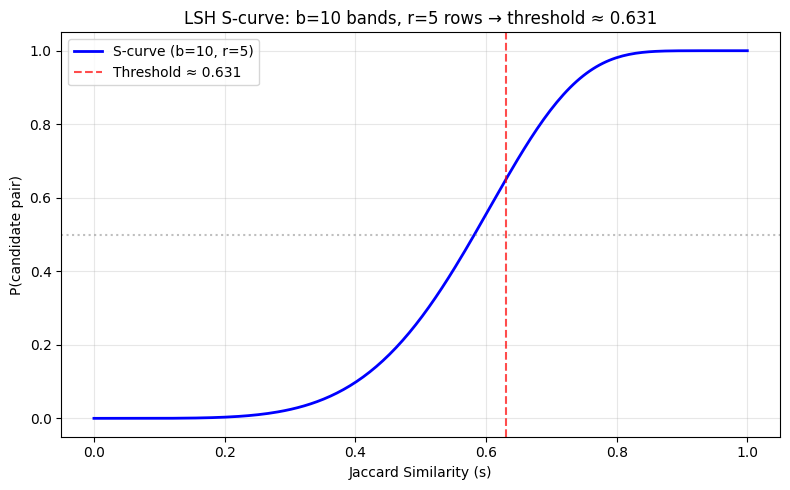

In [9]:
## 3.9 S-curve Visualization

import matplotlib.pyplot as plt
import numpy as np

b_val = config.LSH_NUM_BANDS
r_val = config.LSH_ROWS_PER_BAND

s = np.linspace(0, 1, 200)
p = 1 - (1 - s**r_val)**b_val

# Approximate threshold where P ≈ 0.5
threshold = (1 / b_val) ** (1 / r_val)

plt.figure(figsize=(8, 5))
plt.plot(s, p, 'b-', linewidth=2, label=f'S-curve (b={b_val}, r={r_val})')
plt.axvline(x=threshold, color='r', linestyle='--', alpha=0.7, label=f'Threshold ≈ {threshold:.3f}')
plt.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5)
plt.xlabel('Jaccard Similarity (s)')
plt.ylabel('P(candidate pair)')
plt.title(f'LSH S-curve: b={b_val} bands, r={r_val} rows → threshold ≈ {threshold:.3f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Kết luận

- [ ] Shingling tạo đúng word trigrams
- [ ] MinHash estimate xấp xỉ exact Jaccard
- [ ] LSH banding tìm đúng candidate pairs
- [ ] Query trả về kết quả hợp lý
- [ ] S-curve đúng dạng sigmoid với threshold ≈ 0.55